# ProjectAlpha — current best model results

Work in progress. These saved research results use an equal-weight top-20% XGBoost portfolio, a 260-week rolling window, seed 42, and 5 bps per dollar traded. The configuration varies only when a conservative chronological validation gate accepts a challenger.

All inputs to this notebook are included under `reports/best_model/`. Running it does not retrain models or contact cloud services. See `README.md` for architecture, definitions and limitations.


In [1]:
from pathlib import Path
import json
import pandas as pd
ROOT = Path('reports/best_model')
summary = json.loads((ROOT/'summary.json').read_text())
print(json.dumps(summary, indent=2))


{
  "model": "XGBoost regression with protected chronological selection",
  "score_start": "2022-01-05",
  "last_realized_score_date": "2026-02-11",
  "data_available_through": "2026-02-18",
  "window_weeks": 260,
  "cost_bps_per_dollar_traded": 5,
  "seed": 42,
  "selected_challenger_dates": 14,
  "configuration_counts": {
    "incumbent": 202,
    "larger_child": 5,
    "shallower_depth": 5,
    "stronger_l2": 4
  },
  "metrics": {
    "return_weeks": 215,
    "annualized_stock_return": 0.182049434842646,
    "annualized_net_stock_return": 0.1551933200300683,
    "annualized_active_return": 0.0662588745685585,
    "net_active_return": 0.0394027597559808,
    "active_ir": 0.6317559382248801,
    "net_cumulative_active_return": 0.1629152566833824,
    "q1_capture": 0.2449427108846786,
    "rank_ic": 0.0101631219198467,
    "ndcg_at_50": 0.5097491499769287,
    "turnover": 0.51653718580821,
    "annualized_transaction_cost": 0.0268561148125777,
    "total_transaction_cost": 0.1110397054

In [2]:
config = json.loads(Path('configs/best_xgboost.json').read_text())
print(json.dumps(config, indent=2))


{
  "base_parameters": {
    "estimator": "XGBRegressor",
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "device": "cpu",
    "random_state": 42,
    "n_jobs": 1,
    "colsample_bytree": 0.8,
    "learning_rate": 0.025,
    "max_depth": 3,
    "min_child_weight": 10,
    "n_estimators": 50,
    "subsample": 0.8
  },
  "reg_lambda": "Unspecified: original XGBoost default 1",
  "rolling_weeks": 260,
  "ensemble_seeds": [
    42
  ],
  "challengers": [
    {
      "max_depth": 2
    },
    {
      "min_child_weight": 20
    },
    {
      "reg_lambda": 2.0
    }
  ],
  "selection": {
    "folds": 4,
    "gap_weeks": 1,
    "cost_bps": 5,
    "min_ir_gain": 0.1,
    "min_annual_net_active_gain": 0.005,
    "min_fold_ir_wins": 3,
    "max_fold_ir_loss": 0.25,
    "block_bootstrap_weeks": 4,
    "bootstrap_replicates": 500,
    "required_gain_10th_percentile": "> 0"
  },
  "note": "Each challenger changes one parameter. The reported result uses dated choices, not one glo

In [3]:
yearly = pd.read_csv(ROOT/'yearly_performance.csv')
print(yearly.round(4).to_string(index=False))
print('2026 is a partial year; annualized values are not full-year realized returns.')


 year  weeks  annualized_stock_return  annualized_net_stock_return  annualized_active_return  net_active_return  active_ir
 2022     52                  -0.0749                      -0.0981                   -0.0067            -0.0299    -0.4110
 2023     52                   0.1842                       0.1542                    0.0076            -0.0225    -0.4964
 2024     52                   0.3431                       0.3163                    0.1585             0.1317     2.2259
 2025     53                   0.2420                       0.2144                    0.0984             0.0707     1.0151
 2026      6                   0.4650                       0.4404                    0.1236             0.0991     2.3384
2026 is a partial year; annualized values are not full-year realized returns.


In [4]:
choices = pd.read_csv(ROOT/'weekly_configurations.csv')
print(choices.candidate.value_counts().to_string())
print('All dated parameters and gate checks: reports/best_model/weekly_configurations.csv')


candidate
incumbent          202
larger_child         5
shallower_depth      5
stronger_l2          4
All dated parameters and gate checks: reports/best_model/weekly_configurations.csv


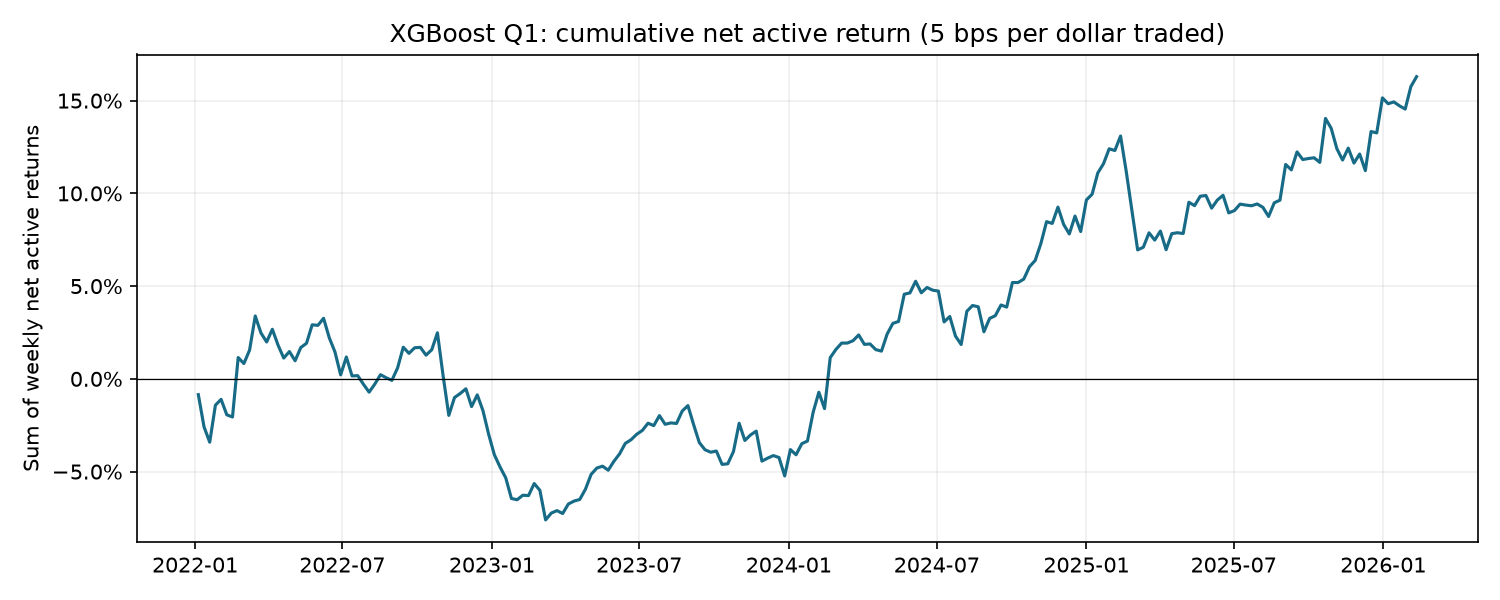

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'cumulative_net_active.png')))
